## Electric Guitar ##  
The solid body of an electric guitar does not resonate, instead, the string signal is read by a pickup and converted to voltage which is outputted by speakers. This results in less energy decay and a longer sustained note. Furthermore, the sound can be modified during the signal transfer to the speakers.

**The String**: Same principle as acoustic but electric guitar string are made of ferromagnetic materials. Thus, they are weightier. In concerns of sound, we consider two string types: solid string and wound string. The key difference is stiffness, under high stiffness, the string behaves like a bar so higher partials go progressively sharp $f_n \approx n \cdot f_0 \sqrt{(1+B_n)^2}$ while a wound string avoids this stiffness.

Mass also changes the drive of the string.

**The Body**

**The Pickup**

**Post-Pickup**

In [14]:
%matplotlib inline
import numpy as np, wave, struct
import matplotlib.pyplot as plt
import scipy
from IPython.display import display, Audio

In [15]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # repo root
from realsound import pluck_string, make_scale, play_sequence, measure_frequency

In [16]:
def pluck_string_electric(f, beta=0.1, duration=3.0, fs=44100, rho=0.998, b=0.5):
    D = fs / f - b                        
    N = int(D)
    frac = D - N
    p = max(int(beta * N), 1)
    pluck = np.concatenate((np.linspace(0, 1, p), np.linspace(1, 0, N - p)))
    L = N + 2
    buf = np.zeros(L); buf[:N] = pluck
    out = np.zeros(int(fs * duration))
    w = 0; last = 0.0
    for i in range(len(out)):
        r0 = (w - N) % L                  
        r1 = (w - N - 1) % L              
        y = (1 - frac) * buf[r0] + frac * buf[r1]
        buf[w] = ((1 - b) * y + b * last) * rho    # loop filter, then round-trip loss
        last = y; out[i] = y; w = (w + 1) % L
    return out

In [17]:
def dc_block(x, fs=44100, fc=7.0):
    a = np.exp(-2 * np.pi * fc / fs)      # pole radius <-> cutoff in Hz
    return scipy.signal.lfilter([1, -1], [1, -a], x)

In [18]:
def plot_waveform_spectrum(output, name="output", fs=44100, fmax=8000):
    fig, ax = plt.subplots(2, 1, figsize=(10, 6))
    t_ms = np.arange(len(output)) / fs * 1000
    ax[0].plot(t_ms, output)
    ax[0].set_title(f"waveform - {name}"); ax[0].set_xlabel('ms'); ax[0].set_ylabel('amp')
    X = np.abs(np.fft.rfft(output * np.hanning(len(output))))
    f = np.fft.rfftfreq(len(output), 1 / fs)
    ref = X[f > 20].max()
    ax[1].plot(f, 20 * np.log10(X / ref + 1e-9))
    ax[1].set_xlim(0, fmax); ax[1].set_ylim(-80, 5)
    ax[1].set_title(f"spectrum - {name}"); ax[1].set_xlabel('Hz'); ax[1].set_ylabel('dB')
    plt.tight_layout(); plt.show()

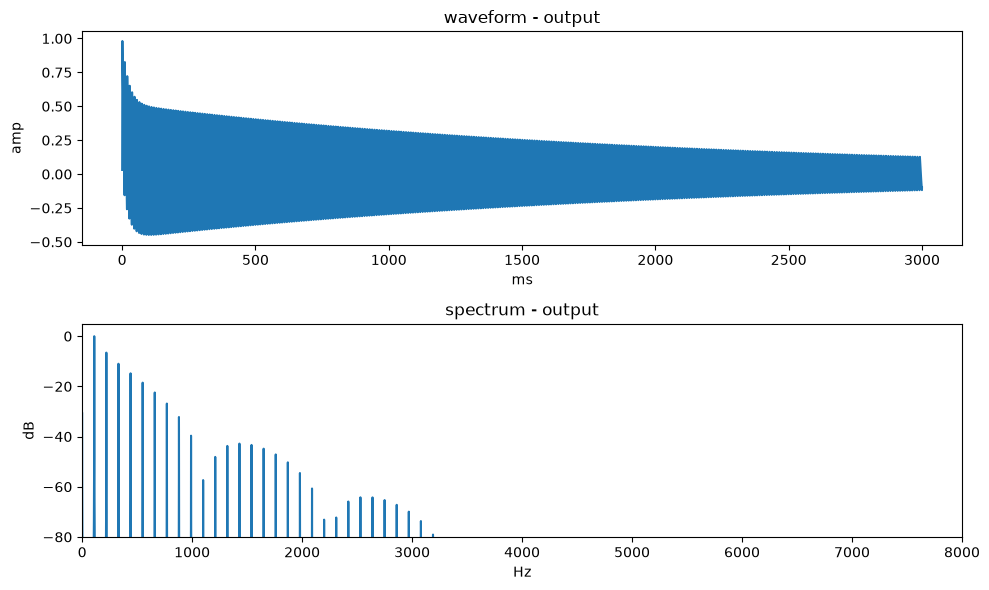

In [19]:
out = pluck_string_electric(f=110, beta=0.1, rho=0.996, b=0.1, duration=3.0)
out = dc_block(out)
plot_waveform_spectrum(out)
display(Audio(out,rate=44100))

In [20]:
def frac_comb(x, D):
    """y[n] = x[n] - x[n-D], with fractional D by linear interpolation.
 
    WHY A MINUS SIGN. d'Alembert: string motion at any point is the sum of a
    right-going and a left-going wave. The left-going wave at the pickup IS the
    right-going wave after it has run to the bridge and reflected -- and a pinned
    termination reflects with INVERSION. So the pickup sees the wave minus a
    delayed copy of itself. The minus is the bridge; the delay is the round trip
    pickup -> bridge -> pickup.
    """
    i = int(np.floor(D)); f = D - i
    d = np.zeros_like(x)
    d[i:]   = (1 - f) * x[:len(x) - i]
    if i + 1 < len(x):
        d[i+1:] += f * x[:len(x) - i - 1]
    return x - d

In [21]:
def rlc_lowpass(x, fs, L, C, R):
    """The pickup's ELECTRICAL resonance -- the thing that makes a pickup sound
    like a pickup.
 
    The coil is a big inductor (henries). Cable + tone-cap capacitance hangs off
    it. Series RLC read across the capacitor:
 
        H(s) = 1 / (LC s^2 + RC s + 1)
        f_res = 1/(2*pi*sqrt(LC))        Q = sqrt(L/C)/R
 
    Below f_res it is flat; at f_res it PEAKS by ~Q; above it falls at
    -12 dB/oct. That peak is the "presence" of an electric guitar.
      single coil : less inductance -> higher, brighter peak (~4-5 kHz)
      humbucker   : more inductance -> lower, fatter peak  (~2-3 kHz)
    The tone knob adds C, which drags f_res down and damps it.
 
    R here lumps coil DC resistance plus the loading the volume/tone pots
    reflect into the circuit -- pot loading is what keeps real Q down near 2-5
    instead of the ~12 the bare coil would give.
    """
    f_res = 1 / (2 * np.pi * np.sqrt(L * C))
    Q = np.sqrt(L / C) / R
    # RBJ biquad, bilinear transform of H(s) above (w0 prewarped by tan())
    w0 = 2 * np.pi * f_res / fs
    alpha = np.sin(w0) / (2 * Q)
    cw = np.cos(w0)
    b = np.array([(1 - cw) / 2, 1 - cw, (1 - cw) / 2])
    a = np.array([1 + alpha, -2 * cw, 1 - alpha])
    return scipy.signal.lfilter(b / a[0], a / a[0], x), f_res, Q

In [22]:
def pickup(x, f0, fs=44100, beta_p=0.12, coil_spacing_mm=0.0, scale_mm=648.0,
           L=2.2, C=470e-12, R=22e3, velocity=True, normalize=True,
           verbose=False):
    """Magnetic pickup: string DISPLACEMENT in -> coil VOLTAGE out.
 
    beta_p          : pickup distance from bridge, as a fraction of scale length
                      (~0.08 bridge pickup, ~0.25 neck pickup).
                      For a humbucker this is the MIDPOINT of the two coils, not
                      either coil: summing two sensing points factors exactly into
                      |cos(w*s/2c)| * |sin(w*x_mid/c)|, so the position comb is set
                      by the midpoint. Using coil 1 instead is a 0.5 full-scale error.
    coil_spacing_mm : 0 for a single coil. ~18 for a humbucker's two coils.
    L, C, R         : the coil's electrical resonance (see rlc_lowpass)
    """
    N = fs / f0                      # samples per period = round trip of the string
 
    # ---- 1. FARADAY. Coil voltage tracks dPhi/dt, so the pickup senses VELOCITY,
    # not displacement. Differentiation multiplies harmonic n by n: the pluck's
    # 1/n^2 displacement spectrum becomes 1/n. -6 dB/oct instead of -12.
    # It also has exactly zero gain at DC, so it removes the pluck's DC offset
    # for free -- a motionless displaced string induces no voltage.
    y = np.diff(x, prepend=0.0) if velocity else x.copy()
 
    # ---- 2. POSITION COMB. Delay = round trip pickup->bridge->pickup = beta_p*N.
    # Nulls land at multiples of f0/beta_p, i.e. it kills every (1/beta_p)th
    # harmonic -- the ones with a node at the pickup.
    y = frac_comb(y, beta_p * N)
 
    # ---- 3. TWO COILS (humbucker). NOT an aperture blur -- it is a second comb
    # from sensing the string at two places and summing. Spatial offset s mm maps
    # to s*N/(2*scale) samples, because the wave covers 2*scale mm per period.
    if coil_spacing_mm > 0:
        d = coil_spacing_mm * N / (2 * scale_mm)
        i = int(np.floor(d)); f = d - i
        y2 = np.zeros_like(y)
        y2[i:] = (1 - f) * y[:len(y) - i]
        if i + 1 < len(y):
            y2[i+1:] += f * y[:len(y) - i - 1]
        y = 0.5 * (y + y2)
 
    # ---- 4. ELECTRICAL RESONANCE.
    y, f_res, Q = rlc_lowpass(y, fs, L, C, R)
 
    if verbose:
        print(f"  comb delay {beta_p*N:.1f} samp -> nulls every {f0/beta_p:.0f} Hz "
              f"(harmonic {1/beta_p:.1f})")
        if coil_spacing_mm > 0:
            print(f"  coil comb  {coil_spacing_mm*N/(2*scale_mm):.1f} samp -> "
                  f"first null {scale_mm*f0/coil_spacing_mm:.0f} Hz")
        print(f"  resonance  f_res={f_res:.0f} Hz  Q={Q:.2f}")
 
    if normalize and np.abs(y).max() > 0:
        y = y / np.abs(y).max()
    return y

This is quite boring. Changes in pickup does not fundamentally change the sound. We want fictional noise on fictional instruments, modifying existing instruments can only give so much space for freedom. We close this by introducing nonlinearity and then move on to primitive simulation. 

In [23]:
def oversampled(fn, x, factor=8):
    """Apply a memoryless nonlinearity at `factor` times the sample rate.

    A nonlinearity has infinite bandwidth in principle: tanh of a band-limited
    signal is not band-limited. At the base rate those new partials have nowhere
    to go, so they mirror around fs/2 and reappear at inharmonic frequencies --
    audibly wrong in a way no amount of filtering afterwards can undo, because
    by then the aliased partials are indistinguishable from real ones.

    Running the shaper at N x fs pushes the fold-back point N times higher, and
    the decimating filter removes everything above the original Nyquist BEFORE
    the rate drops. The order matters: band-limit, then decimate.

    factor=8 is enough for tanh-like curves. Hard clipping and folding have
    corners, hence infinite harmonic series, and want 16-32 -- and even then
    they alias somewhat. There is no factor that makes a discontinuous shaper
    clean; you can only push the residue down.
    """
    up = scipy.signal.resample_poly(x, factor, 1)
    return scipy.signal.resample_poly(fn(up), 1, factor)

In [24]:
def _tanh(u):
    """Soft saturation. Smooth, odd, and its derivative falls off gradually,
    so harmonic amplitudes decay quickly -- 'warm' rather than 'harsh'."""
    return np.tanh(u)


def _hard(u):
    """Hard clip. Odd, but the corners are derivative discontinuities, which
    means a harmonic series that decays as 1/n instead of exponentially. This
    is the buzzy, fizzy one, and the one that aliases worst."""
    return np.clip(u, -1.0, 1.0)


def _cubic(u):
    """Cubic soft clip -- the only shape here with a closed-form answer, which
    makes it the one you can unit-test.

    Below the clamp it is exactly 1.5*(u - u^3/3). Since sin^3 = (3sin - sin3)/4,
    a sine of amplitude a in gives EXACTLY two partials out:

        h1 = 1.5a - 0.375 a^3        h3 = a^3 / 8

    and nothing else. No h2 (the curve is odd), no h5 (the polynomial is cubic).
    Verified to 0.01 dB. Use this as the ground truth when checking that an
    oversampling or gain-staging change did not break anything.
    """
    return np.where(np.abs(u) < 1.0, 1.5 * (u - u**3 / 3.0), 1.5 * np.sign(u) * (2.0 / 3.0))


def _fold(u):
    """Wavefolder. NOT a saturator -- it is NON-MONOTONIC: past the threshold the
    output goes back DOWN as the input keeps rising.

    Nothing in acoustics does this. A saturator runs out of headroom, which is
    what every physical transducer, tube and magnetic circuit does. A folder
    reverses, and that reversal manufactures very high-order partials at
    moderate drive rather than requiring extreme drive.

    This is the shape to reach for when the goal is a sound with no physical
    referent. Drive here is a timbre control, not a loudness control: each
    additional fold restructures the spectrum instead of just adding grit.
    """
    return np.sin(u * np.pi / 2.0)


SHAPES = {'tanh': _tanh, 'hard': _hard, 'cubic': _cubic, 'fold': _fold}

In [25]:
def nonlinear(x, kind='tanh', drive=1.0, bias=0.0, factor=8,
              mix=1.0, normalize=True):
    """Memoryless nonlinearity with anti-aliasing. The library's only source of
    new spectrum.

    kind   : 'tanh' | 'hard' | 'cubic' | 'fold'   (see each above)
    drive  : input gain into the curve. This is the real control -- a shaper is
             only nonlinear in proportion to how hard you hit it. At drive well
             below 1 every shape here is indistinguishable from a wire.
    bias   : DC added BEFORE the curve, removed after.

             THIS IS THE ONLY SYMMETRY CONTROL AND IT MATTERS MORE THAN `kind`.
             All four curves are odd, and an odd function applied to a signal
             produces only ODD harmonics -- measured h2 at -302 dB, i.e. exactly
             nothing. Offset the signal so it sits on an asymmetric part of the
             curve and even harmonics appear: bias 0.3 into tanh puts h2 at
             -23.1 dB. Odd-only reads as hollow and clarinet-like; even present
             reads as warm and vocal. That is a tube amp's grid bias, and it is
             also why a DC offset upstream is not cosmetic -- it silently
             changes the harmonic content of everything downstream.

    factor : oversampling ratio. Do not set to 1 unless you are demonstrating
             what aliasing sounds like.
    mix    : 0 = dry, 1 = fully shaped. Parallel blend, which keeps low-level
             detail that heavy shaping would otherwise flatten.

    DC removal is a plain mean subtraction -- exact, and fine because this
    project renders offline. A real-time version needs a one-pole high-pass
    instead, since the mean is not available until the signal is over.
    """
    if kind not in SHAPES:
        raise ValueError(f"kind must be one of {sorted(SHAPES)}, got {kind!r}")
    f = SHAPES[kind]
    shaped = oversampled(lambda u: f(drive * u + bias), x, factor)
    shaped = shaped[:len(x)]
    shaped = shaped - shaped.mean()              # undo the bias, keep its effect
    y = mix * shaped + (1.0 - mix) * x[:len(shaped)]
    if normalize and np.abs(y).max() > 0:
        y = y / np.abs(y).max()
    return y

In [26]:
def harmonic_report(y, f0, fs=44100, n=8):
    """Levels of the first n harmonics in dB relative to h1, plus total
    inharmonic energy -- the number that tells you whether you aliased.

    Inharmonic energy is the honest test of a nonlinearity: harmonics are the
    point, anything that is NOT a harmonic is damage.
    """
    A = np.abs(np.fft.rfft(y * np.hanning(len(y))))
    fr = np.fft.rfftfreq(len(y), 1 / fs)
    idx = [np.argmin(np.abs(fr - k * f0)) for k in range(1, n + 1)]
    ref = A[idx[0]]
    lv = [20 * np.log10(A[max(0, i - 2):i + 3].max() / ref + 1e-18) for i in idx]
    mask = np.ones(len(A), bool)
    for k in range(1, int(fr[-1] / f0) + 1):
        i = np.argmin(np.abs(fr - k * f0)); mask[max(0, i - 3):i + 4] = False
    mask[:3] = False
    return lv, 20 * np.log10(np.sqrt((A[mask]**2).sum()) / ref + 1e-18)

In [44]:
def play(name, x, show=True):
    save(name, x)
    if show:
        print(name)
        display(Audio(x, rate=fs))
    return x

In [45]:
fs=44100
string = pickup(pluck_string_electric(f=110, beta=0.1, rho=0.996, b=0.1, duration=3.0),
                110, beta_p=0.08)                                  # plucked, decaying
sine   = np.sin(2 * np.pi * 220 * np.arange(3 * fs) / fs)          # for measuring
noise  = np.random.default_rng(0).standard_normal(3 * fs) * 0.3    # for texture

In [46]:
play('ex1.wav', nonlinear(string, 'tanh', drive=1))

ex1.wav


array([0.07260985, 0.39381407, 0.71994896, ..., 0.08132223, 0.09680153,
       0.09909535], shape=(132300,))

In [47]:
play('ex2a.wav', nonlinear(string, 'tanh',  drive=4))   # smooth, fast-decaying harmonics
play('ex2b.wav', nonlinear(string, 'hard',  drive=4))   # corners -> 1/n series, buzzy
play('ex2c.wav', nonlinear(string, 'cubic', drive=4))   # h3 only until it clamps

ex2a.wav


ex2b.wav


ex2c.wav


array([0.33134501, 0.9650744 , 0.91088722, ..., 0.34105944, 0.4011647 ,
       0.41025557], shape=(132300,))

In [48]:
play('ex3a.wav', nonlinear(string, 'tanh', drive=6, bias=0.0))   # h2 at -195 dB: none
play('ex3b.wav', nonlinear(string, 'tanh', drive=6, bias=0.3))   # h2 at  -23 dB: warm
play('ex3c.wav', nonlinear(string, 'tanh', drive=6, bias=0.8))   # h2 at  -15 dB: vocal

ex3a.wav


ex3b.wav


ex3c.wav


array([-0.05031241,  0.29916826,  0.23747036, ...,  0.16316023,
        0.14559916,  0.20242017], shape=(132300,))

In [49]:
play('ex4.wav', nonlinear(string, 'hard', drive=12, mix=0.4))

ex4.wav


array([0.26226579, 0.61874524, 0.75454388, ..., 0.33765529, 0.3948625 ,
       0.40535512], shape=(132300,))

In [50]:
for d in (2, 3, 5, 9):
    save(f'ex5_fold{d}.wav', nonlinear(string, 'fold', drive=d, factor=16))

In [51]:
play('ex6_aliased.wav', nonlinear(string, 'fold', drive=3, factor=1))

ex6_aliased.wav


array([0.33529622, 0.99175275, 0.22478195, ..., 0.29716244, 0.33001831,
       0.36316653], shape=(132300,))

In [52]:
raw = pluck_string_electric(f=110, beta=0.1, rho=0.996, b=0.1, duration=3.0)
raw = np.diff(raw, prepend=0.0)
play('ex7a.wav', rlc_lowpass(nonlinear(raw, 'tanh', drive=8), fs, 2.2, 470e-12, 22e3)[0])
play('ex7b.wav', nonlinear(rlc_lowpass(raw, fs, 2.2, 470e-12, 22e3)[0], 'tanh', drive=8))

ex7a.wav


ex7b.wav


array([0.06319892, 0.35018182, 0.68961963, ..., 0.05250574, 0.06496698,
       0.06827263], shape=(132300,))

In [53]:
lv, inh = harmonic_report(nonlinear(sine, 'tanh', drive=4, bias=0.3), 220, fs)
print('h1..h8 dB:', ' '.join(f'{v:.1f}' for v in lv), '| inharmonic:', f'{inh:.1f}')

h1..h8 dB: 0.0 -23.1 -11.5 -25.8 -19.4 -29.7 -26.9 -34.3 | inharmonic: -119.9


In [ ]:
def tension_modulated_string(f, beta=0.1, duration=2.0, fs=44100, rho=0.999,
                             b=0.5, alpha=0.0, follow_hz=25.0):
    """String whose PITCH depends on how hard it is playing. The second kind of
    nonlinearity -- and the one the waveshaper in NONLINEARITY cannot do.

    THE PHYSICS. `pluck_string` assumes tension is a constant, which is a
    linearisation. A string displaced to amplitude a is geometrically LONGER
    than at rest, and a stiff steel string cannot stretch freely, so the extra
    length shows up as extra tension:

        dT/T ~ (a/L)^2          f = (1/2L) sqrt(T/mu)  ->  f ~ f0 sqrt(1 + alpha a^2)

    Quadratic, not linear -- which is why it is inaudible at normal levels and
    obvious on a hard attack. The note starts sharp and falls to pitch as it
    decays. Very audible on bass and on a heavily plucked low E; it is a large
    part of why a hard attack sounds hard rather than just loud.

    WHY THIS IS NOT A WAVESHAPER. `nonlinear` is memoryless: same input sample,
    same output sample, always. Here the nonlinearity is in the DELAY LENGTH, so
    the string's own amplitude feeds back into its pitch. Memoryless shaping can
    add harmonics but can never move f0; this moves f0 and adds almost no
    harmonics. Verify by measuring pitch early vs late, not by looking at a
    spectrum.

    alpha      : modulation depth. 0 reduces exactly to the linear string.
                 ~0.5-5 is audible, >20 is a synthesiser rather than a string.
    follow_hz  : cutoff of the amplitude follower. The tension responds to the
                 ENVELOPE, not to the waveform -- track the waveform and you are
                 FM-ing the delay line at audio rate, which is a different
                 (and much harsher) instrument.
    """
    D0 = fs / f - b                                   # rest-tension loop delay
    N0 = int(D0)
    p = min(max(int(beta * N0), 1), N0 - 1)
    L = N0 + 2                                        # tension only SHORTENS the delay
    buf = np.zeros(L)
    buf[:N0] = np.concatenate((np.linspace(0, 1, p), np.linspace(1, 0, N0 - p)))
    out = np.zeros(int(fs * duration))
    c_env = 1.0 - np.exp(-2 * np.pi * follow_hz / fs)  # one-pole follower coeff
    w = 0; last = 0.0; env = 0.0
    for i in range(len(out)):
        env += c_env * (abs(last) - env)              # amplitude, not waveform
        D = D0 / np.sqrt(1.0 + alpha * env * env)     # sharper when driven harder
        Ni = int(D); frac = D - Ni
        y = (1 - frac) * buf[(w - Ni) % L] + frac * buf[(w - Ni - 1) % L]
        buf[w] = ((1 - b) * y + b * last) * rho
        last = y; out[i] = y; w = (w + 1) % L
    return out

In [1]:
def speaker_cab_ir(fs=44100, f_lo=90.0, Q_lo=0.9, f_hi=4200.0,
                   breakup=((1800.0, 4.0, 2.0), (3100.0, 3.0, 3.0)),
                   length=0.05):
    """Guitar speaker + box, as an impulse response.

    A guitar speaker is deliberately NOT hi-fi, and every stage here is a
    mechanical fact rather than a taste choice:

      f_lo    : cone-on-suspension-in-a-box resonance. Below it the cone still
                moves but shifts no net air, so output falls at 12 dB/oct.
                Verified: -3 dB at 92 Hz, asymptotic slope -11.9 dB/oct.
      f_hi    : cone MASS. Above this the diaphragm cannot be accelerated fast
                enough to follow the drive. Applied twice (24 dB/oct) because a
                real guitar speaker's top end falls off a cliff -- which is why
                a miked distorted amp is not fizzy even though the signal
                reaching it is. Two 2nd-order lowpasses both at f_hi each give
                -3 dB there, so the combined -3 dB point sits BELOW the design
                corner: measured 3799 Hz for f_hi = 4200. Expected.
      breakup : (f, dB, Q) resonances where the cone stops moving as one piece
                and flexes in modal patterns. These are literally plate modes --
                the same physics as build_body_IR, on a stiffer, lighter, more
                damped plate. Verified +3.9 dB at 1800 Hz (design +4.0).

    Measured slopes steepen near Nyquist (-26 dB/oct at 5-10 kHz, -52 at
    9-18 kHz). That is the bilinear transform putting all its zeros AT Nyquist;
    -24 is the analog asymptote and the digital filter is correct.

    Returned as an IR because the cab is LINEAR, so it convolves exactly like
    the acoustic body -- the electric chain is the acoustic chain with the body
    IR swapped for a cab IR. Drop a measured .wav IR in here instead and nothing
    downstream changes.
    """
    n = int(length * fs)
    y = np.zeros(n); y[0] = 1.0
    stages = [scipy.signal.butter(2, f_lo / (fs / 2), 'highpass', output='sos'),
              scipy.signal.butter(2, f_hi / (fs / 2), 'lowpass', output='sos'),
              scipy.signal.butter(2, f_hi / (fs / 2), 'lowpass', output='sos')]
    for f, gain_db, Q in breakup:                        # RBJ peaking EQ
        w0 = 2 * np.pi * f / fs
        A = 10 ** (gain_db / 40)
        alpha = np.sin(w0) / (2 * Q)
        b = np.array([1 + alpha * A, -2 * np.cos(w0), 1 - alpha * A])
        a = np.array([1 + alpha / A, -2 * np.cos(w0), 1 - alpha / A])
        stages.append(scipy.signal.tf2sos(b / a[0], a / a[0]))
    for s in stages:
        y = scipy.signal.sosfilt(s, y)
    return y / np.abs(y).max()


In [ ]:
def electric_guitar(f=110.0, duration=3.0, fs=44100,
                    beta=0.1, rho=0.996, b=0.1, alpha=0.0,
                    beta_p=0.08, pickup_kind='single',
                    drive=0.0, bias=0.0, shape='tanh', factor=8,
                    cab=True, cab_ir=None, normalize=True, verbose=False):
    """The whole instrument, evaluated IN ORDER.

        string -> velocity -> position comb -> electrical resonance
               -> overdrive -> speaker cab

    Stages 1-4 are linear and commute freely with one another, which is what let
    the acoustic build use commuted synthesis. The overdrive ends that. Swapping
    just the overdrive and the cab, RMS gap relative to signal (RMS-normalised,
    so level differences do not inflate it):

        drive 0.01 -> -71.9 dB      drive 1  -> -10.8 dB
        drive 0.1  -> -37.4 dB      drive 12 ->  -3.1 dB

    So this function evaluates in sequence and must not be reordered for speed.

    drive = 0 bypasses the overdrive: the chain is then fully linear and IS
    commutable again. cab = False bypasses the speaker.

    Sanity checks that hold end to end: measured f0 is 110.000 Hz at drive 0, 4
    and 12 (a memoryless nonlinearity adds harmonics without moving pitch), and
    beta_p = 0.25 nulls h4/h8/h12 at -68/-96/-84 dB as predicted.
    """
    x = tension_modulated_string(f, beta=beta, duration=duration, fs=fs,
                                 rho=rho, b=b, alpha=alpha)
    y, f_res, Q = pickup(x, f, fs=fs, beta_p=beta_p, kind=pickup_kind)
    if drive > 0:
        y = nonlinear(y, shape, drive=drive, bias=bias, factor=factor,
                      normalize=False)
    if cab:
        ir = speaker_cab_ir(fs=fs) if cab_ir is None else cab_ir
        y = scipy.signal.fftconvolve(y, ir)[:len(y)]
    if verbose:
        print(f"  comb nulls every {f / beta_p:.0f} Hz (harmonic {1 / beta_p:.1f})")
        print(f"  pickup resonance {f_res:.0f} Hz  Q={Q:.2f}")
        print(f"  overdrive {'bypassed' if drive <= 0 else f'{shape} drive={drive} bias={bias}'}")
    if normalize and np.abs(y).max() > 0:
        y = y / np.abs(y).max()
    return y
